In [1]:
!pip install ultralytics -q
!pip install lxml -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 32.2 MB/s eta 0:00:00


In [2]:
import os
import cv2
import yaml
import torch
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from pathlib import Path
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!nvidia-smi

Thu May 21 05:09:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
!git clone https://github.com/Shenggan/BCCD_Dataset.git

Cloning into 'BCCD_Dataset'...
remote: Enumerating objects: 800, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 800 (delta 8), reused 6 (delta 6), pack-reused 789 (from 1)
Receiving objects: 100% (800/800), 7.39 MiB | 14.27 MiB/s, done.
Resolving deltas: 100% (379/379), done.


In [5]:
base_path = "/content/BCCD_Dataset/BCCD"

os.listdir(base_path)

['JPEGImages', 'Annotations', 'ImageSets']

In [6]:
classes = ["RBC", "WBC", "Platelets"]

def convert_bbox(size, box):

    dw = 1. / size[0]
    dh = 1. / size[1]

    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0

    w = box[1] - box[0]
    h = box[3] - box[2]

    x *= dw
    w *= dw

    y *= dh
    h *= dh

    return (x, y, w, h)

annotations_path = "/content/BCCD_Dataset/BCCD/Annotations"

labels_path = "/content/BCCD_Dataset/BCCD/labels"

Path(labels_path).mkdir(parents=True, exist_ok=True)

for xml_file in os.listdir(annotations_path):

    tree = ET.parse(os.path.join(annotations_path, xml_file))
    root = tree.getroot()

    size = root.find('size')

    w = int(size.find('width').text)
    h = int(size.find('height').text)

    label_file = open(
        os.path.join(
            labels_path,
            xml_file.replace(".xml", ".txt")
        ),
        "w"
    )

    for obj in root.iter('object'):

        cls = obj.find('name').text

        if cls not in classes:
            continue

        cls_id = classes.index(cls)

        xmlbox = obj.find('bndbox')

        b = (
            float(xmlbox.find('xmin').text),
            float(xmlbox.find('xmax').text),
            float(xmlbox.find('ymin').text),
            float(xmlbox.find('ymax').text)
        )

        bb = convert_bbox((w, h), b)

        label_file.write(
            str(cls_id) + " " +
            " ".join([str(a) for a in bb]) +
            '\n'
        )

    label_file.close()

print("YOLO Label Conversion Complete")

YOLO Label Conversion Complete


In [7]:
images_path = "/content/BCCD_Dataset/BCCD/JPEGImages"

dataset_path = "/content/BCCD_YOLO"

for split in ['train', 'valid', 'test']:

    os.makedirs(f"{dataset_path}/images/{split}", exist_ok=True)
    os.makedirs(f"{dataset_path}/labels/{split}", exist_ok=True)

all_images = os.listdir(images_path)

train_imgs, temp_imgs = train_test_split(
    all_images,
    test_size=0.2,
    random_state=42
)

valid_imgs, test_imgs = train_test_split(
    temp_imgs,
    test_size=0.5,
    random_state=42
)

splits = {
    "train": train_imgs,
    "valid": valid_imgs,
    "test": test_imgs
}

for split, img_list in splits.items():

    for img_name in img_list:

        shutil.copy(
            os.path.join(images_path, img_name),
            f"{dataset_path}/images/{split}/{img_name}"
        )

        label_name = img_name.replace(".jpg", ".txt")

        shutil.copy(
            os.path.join(labels_path, label_name),
            f"{dataset_path}/labels/{split}/{label_name}"
        )

print("Dataset Split Complete")

Dataset Split Complete


In [8]:
data_yaml = """
train: /content/BCCD_YOLO/images/train
val: /content/BCCD_YOLO/images/valid
test: /content/BCCD_YOLO/images/test

nc: 3

names: ['RBC', 'WBC', 'Platelets']
"""

with open("/content/BCCD_YOLO/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml Created")

data.yaml Created


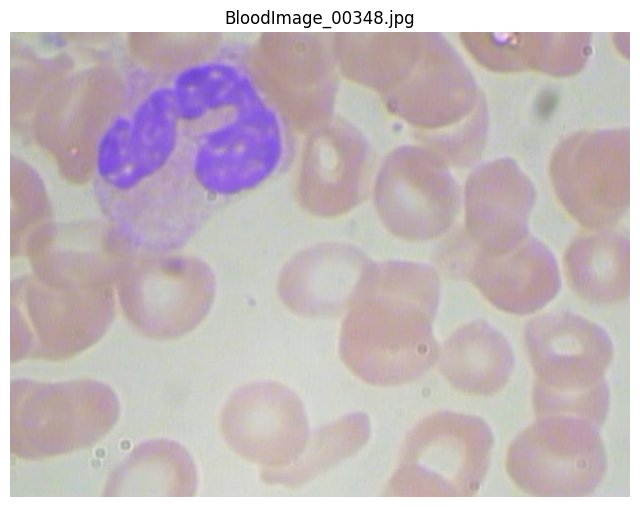

In [9]:
sample_image = random.choice(
    os.listdir("/content/BCCD_YOLO/images/train")
)

img_path = os.path.join(
    "/content/BCCD_YOLO/images/train",
    sample_image
)

img = cv2.imread(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title(sample_image)
plt.axis("off")
plt.show()

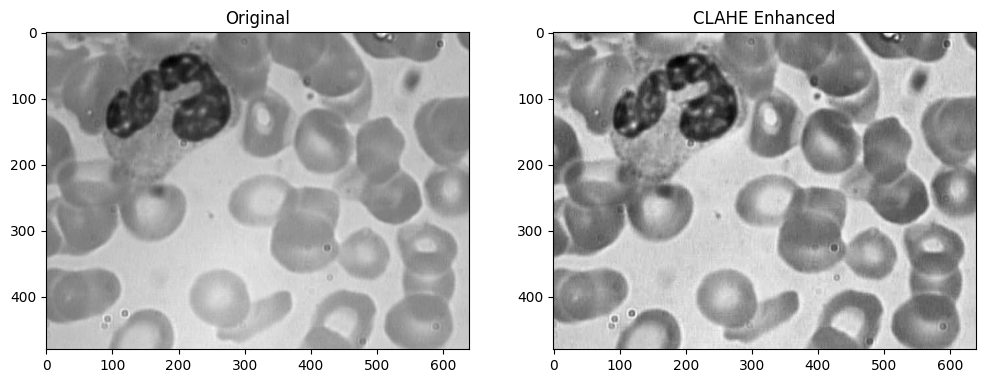

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

enhanced = clahe.apply(gray)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(enhanced, cmap='gray')
plt.title("CLAHE Enhanced")

plt.show()

In [11]:
model = YOLO("yolo11n.pt")

In [12]:
results = model.train(
    data="/content/BCCD_YOLO/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    optimizer="AdamW",
    lr0=0.001,
    project="Rudhiraksha",
    name="YOLOv11_BloodCell"
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/BCCD_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv11_BloodCell, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, pat

In [13]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1094.2±289.3 MB/s, size: 20.5 KB)
val: Scanning /content/BCCD_YOLO/labels/valid.cache... 36 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 36/36 12.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5it/s 1.9s
                   all         36        492      0.918      0.898      0.954      0.674
                   RBC         35        432        0.9      0.775      0.916      0.673
                   WBC         35         35      0.962          1      0.993      0.821
             Platelets         18         25      0.893       0.92      0.953      0.528
Speed: 6.7ms preprocess, 13.1ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.u


==================== Confusion Matrix ====================



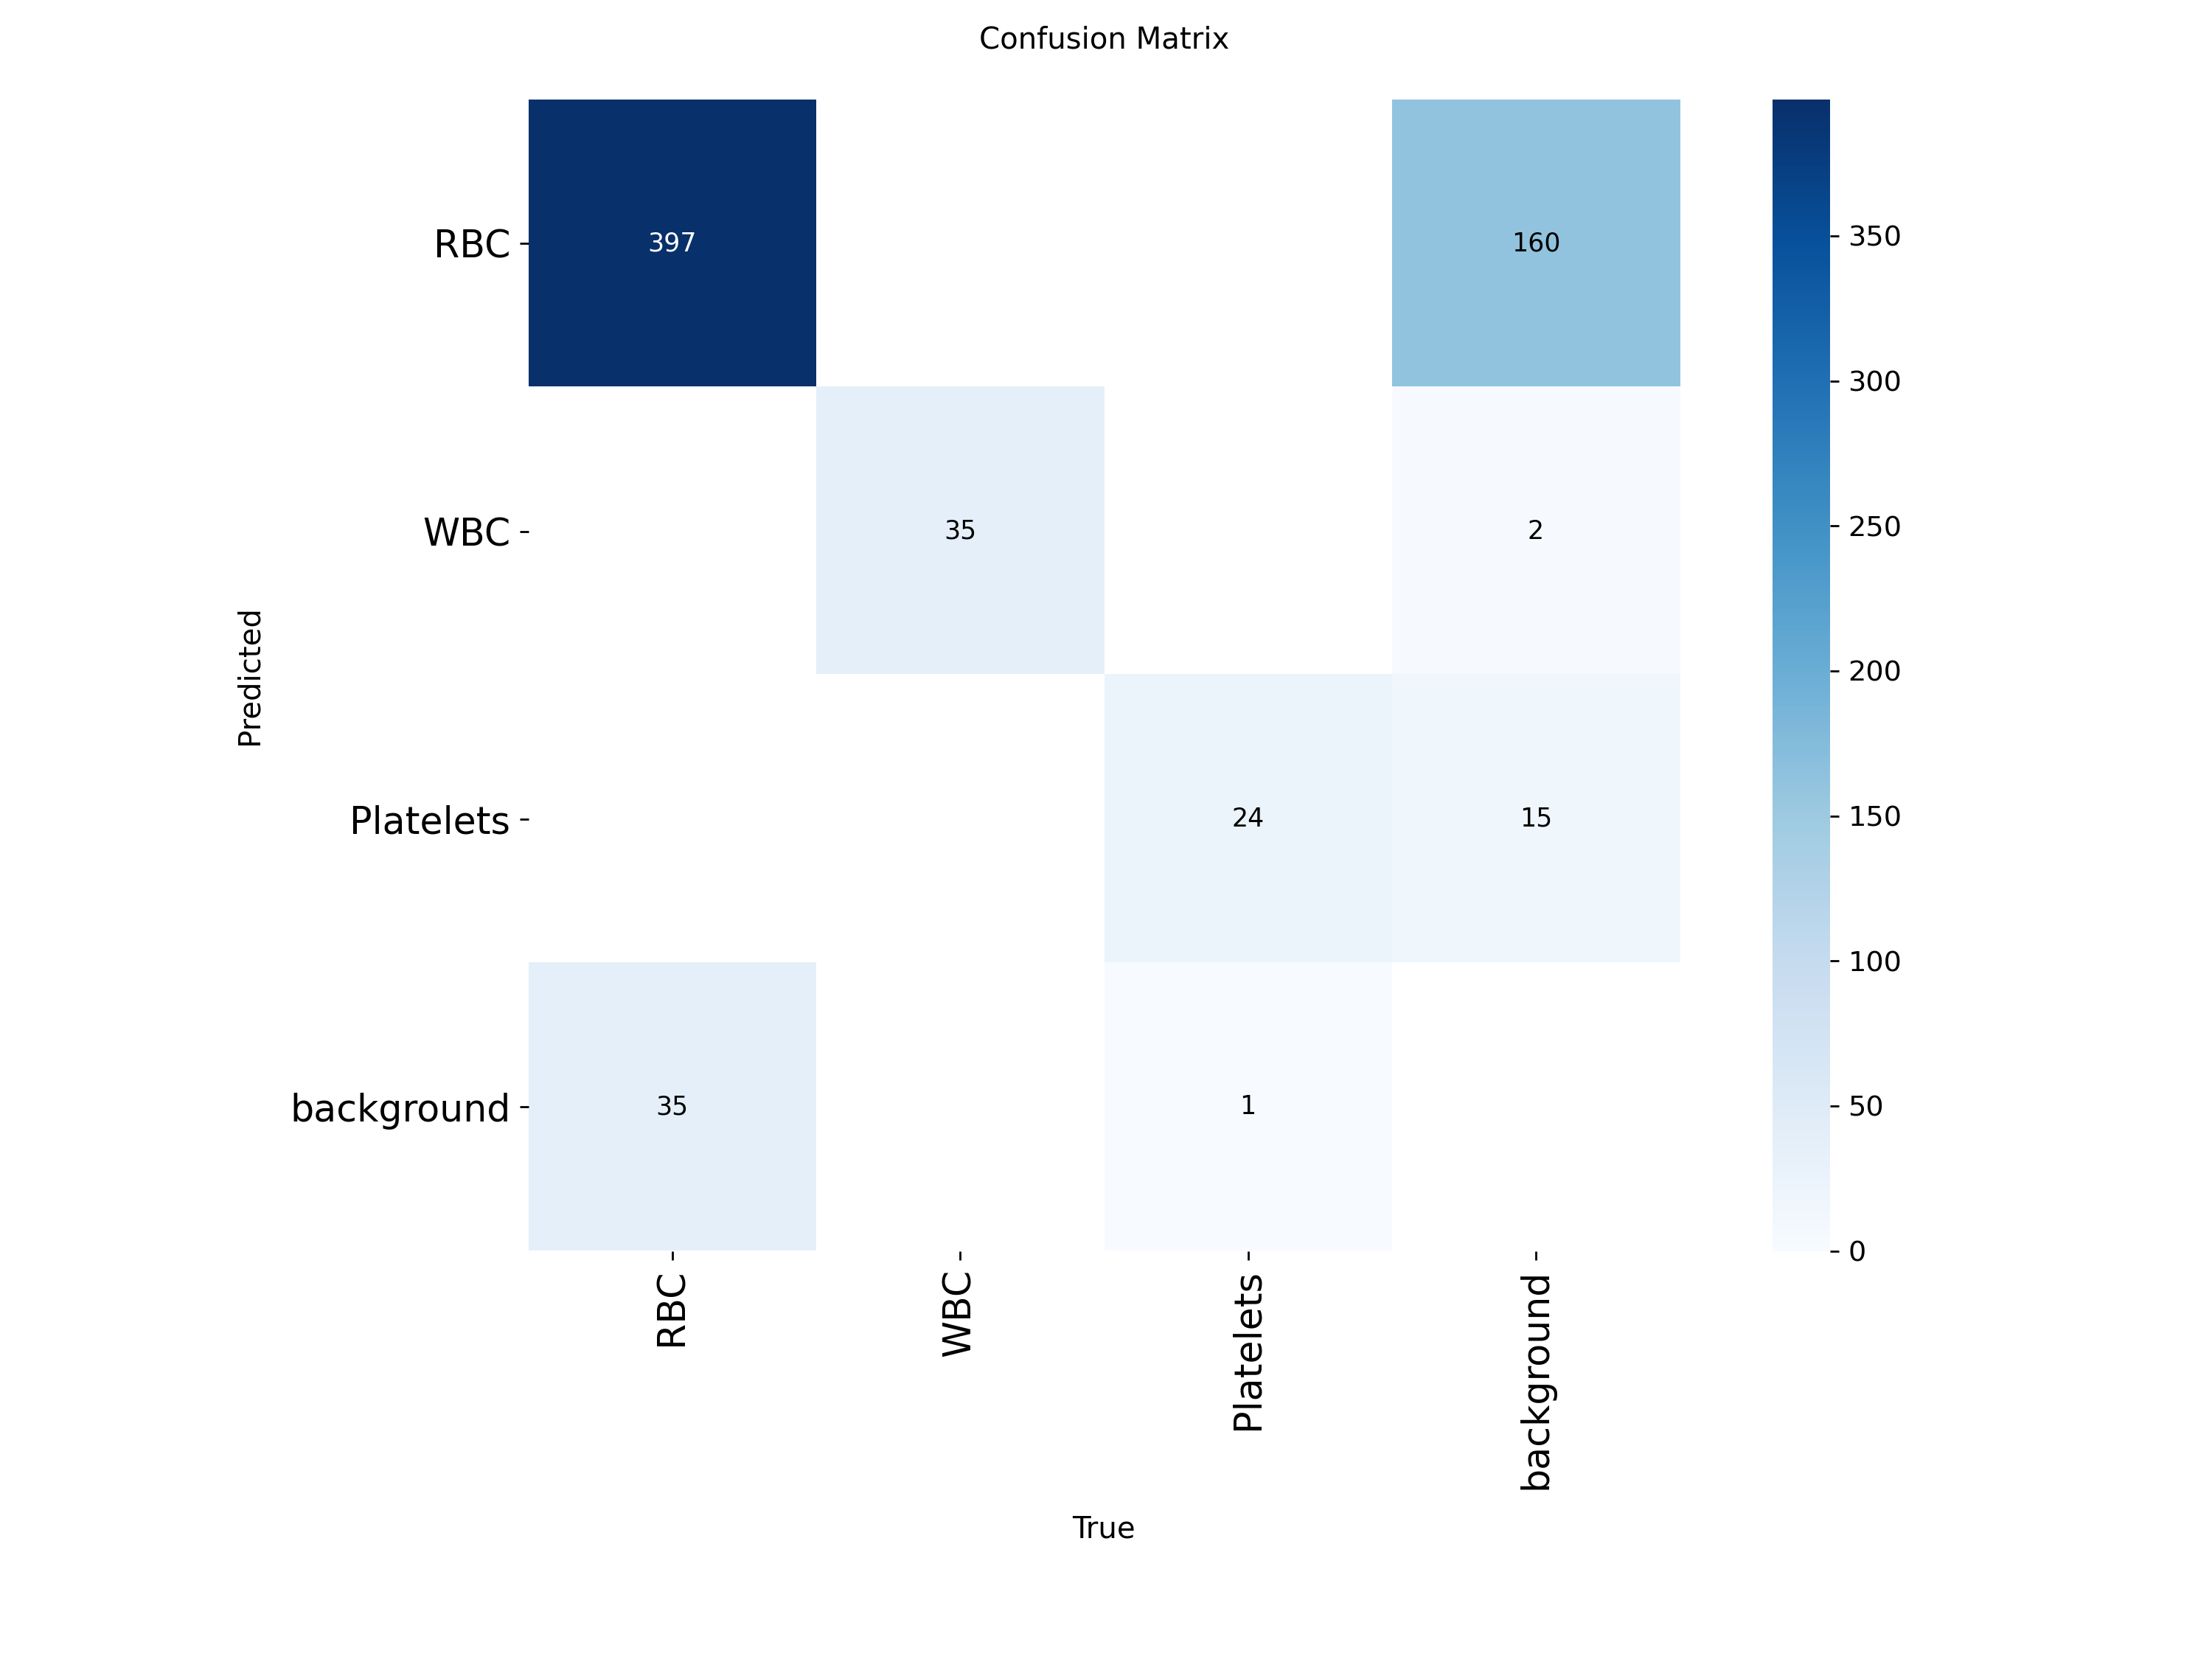


==================== Precision Curve ====================



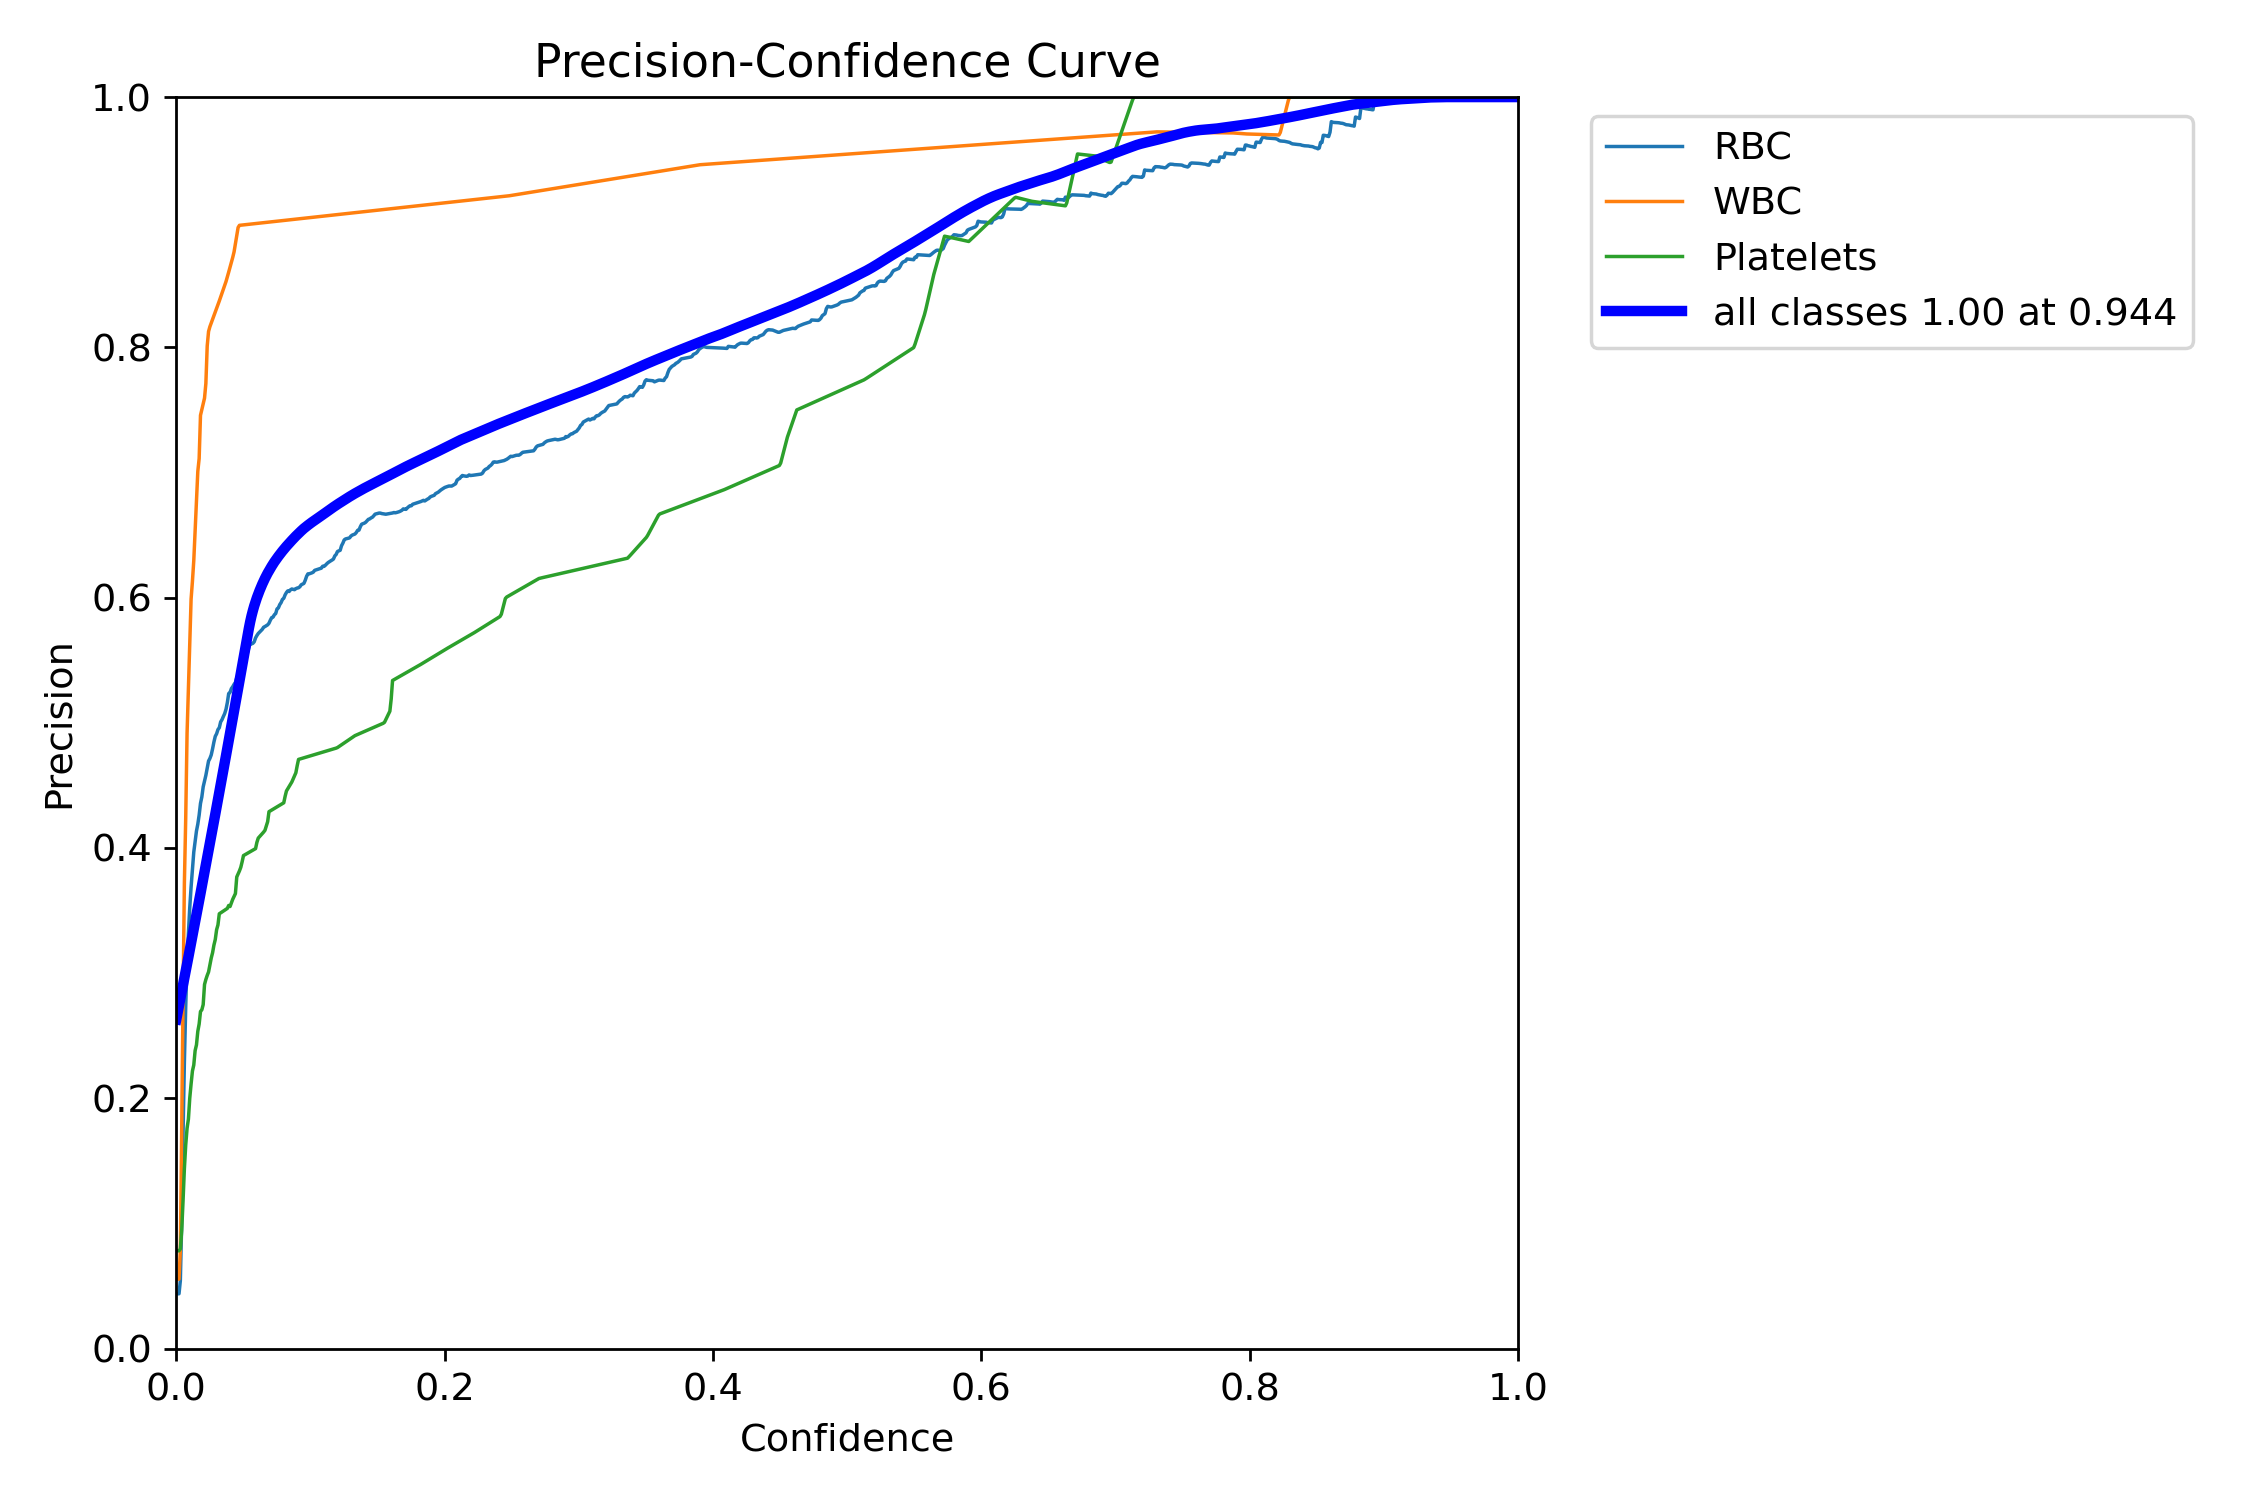


==================== Recall Curve ====================



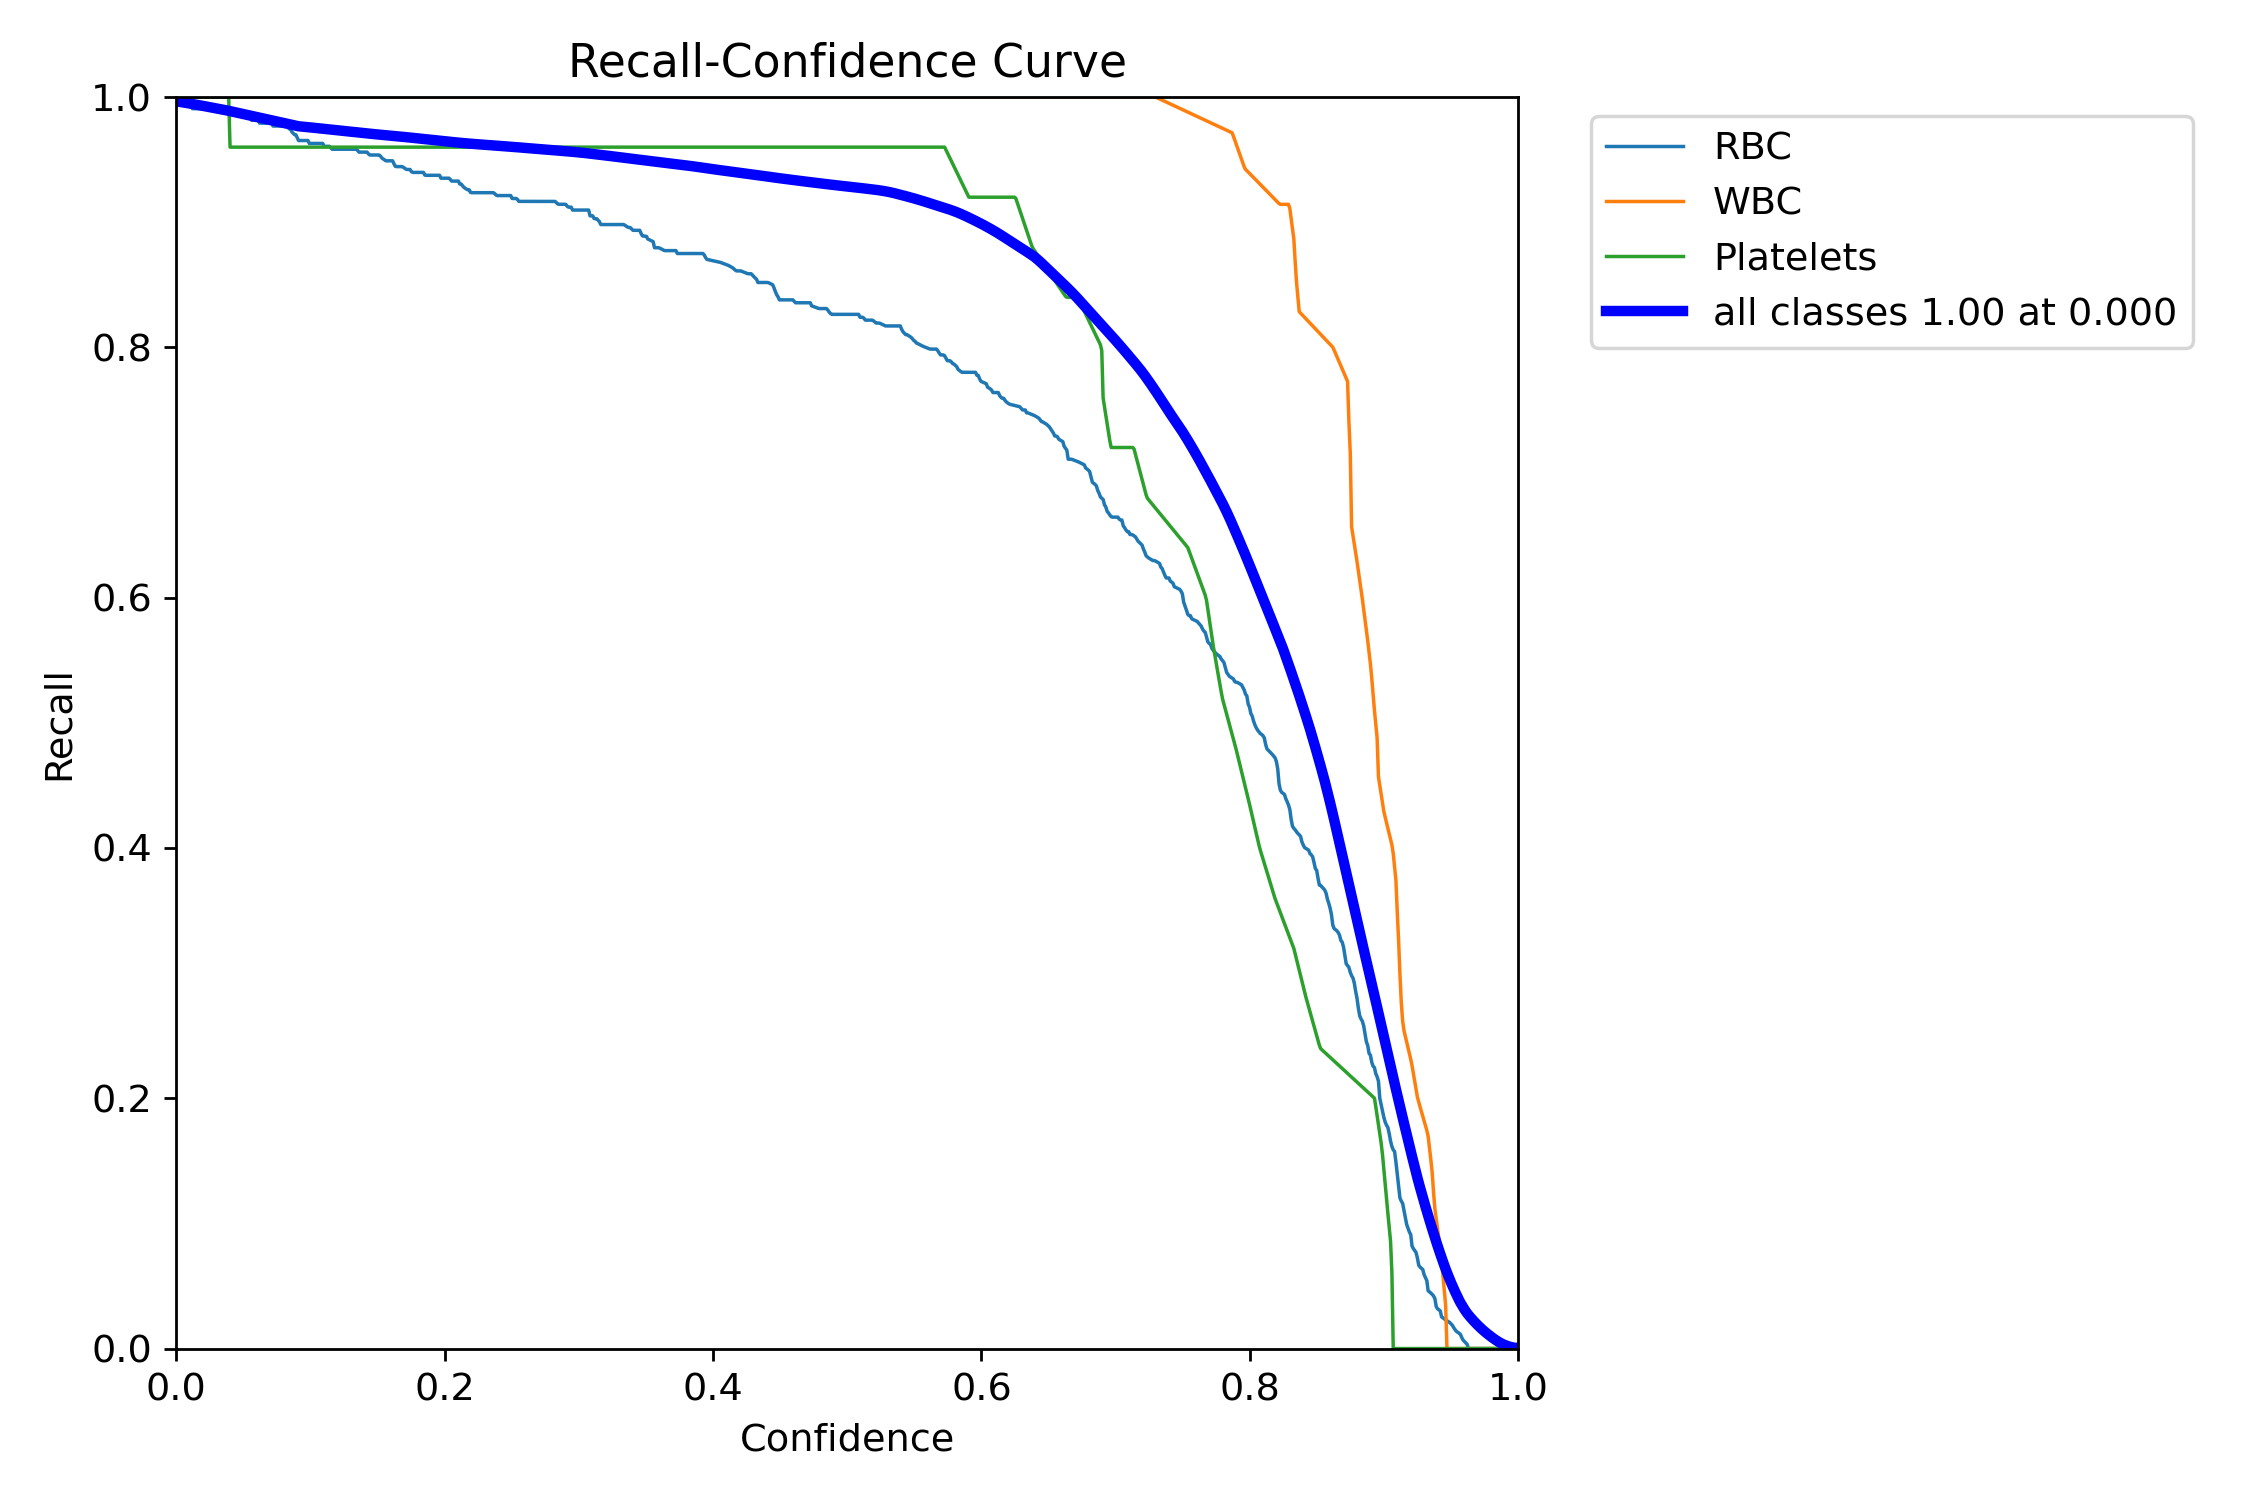


==================== F1 Curve ====================



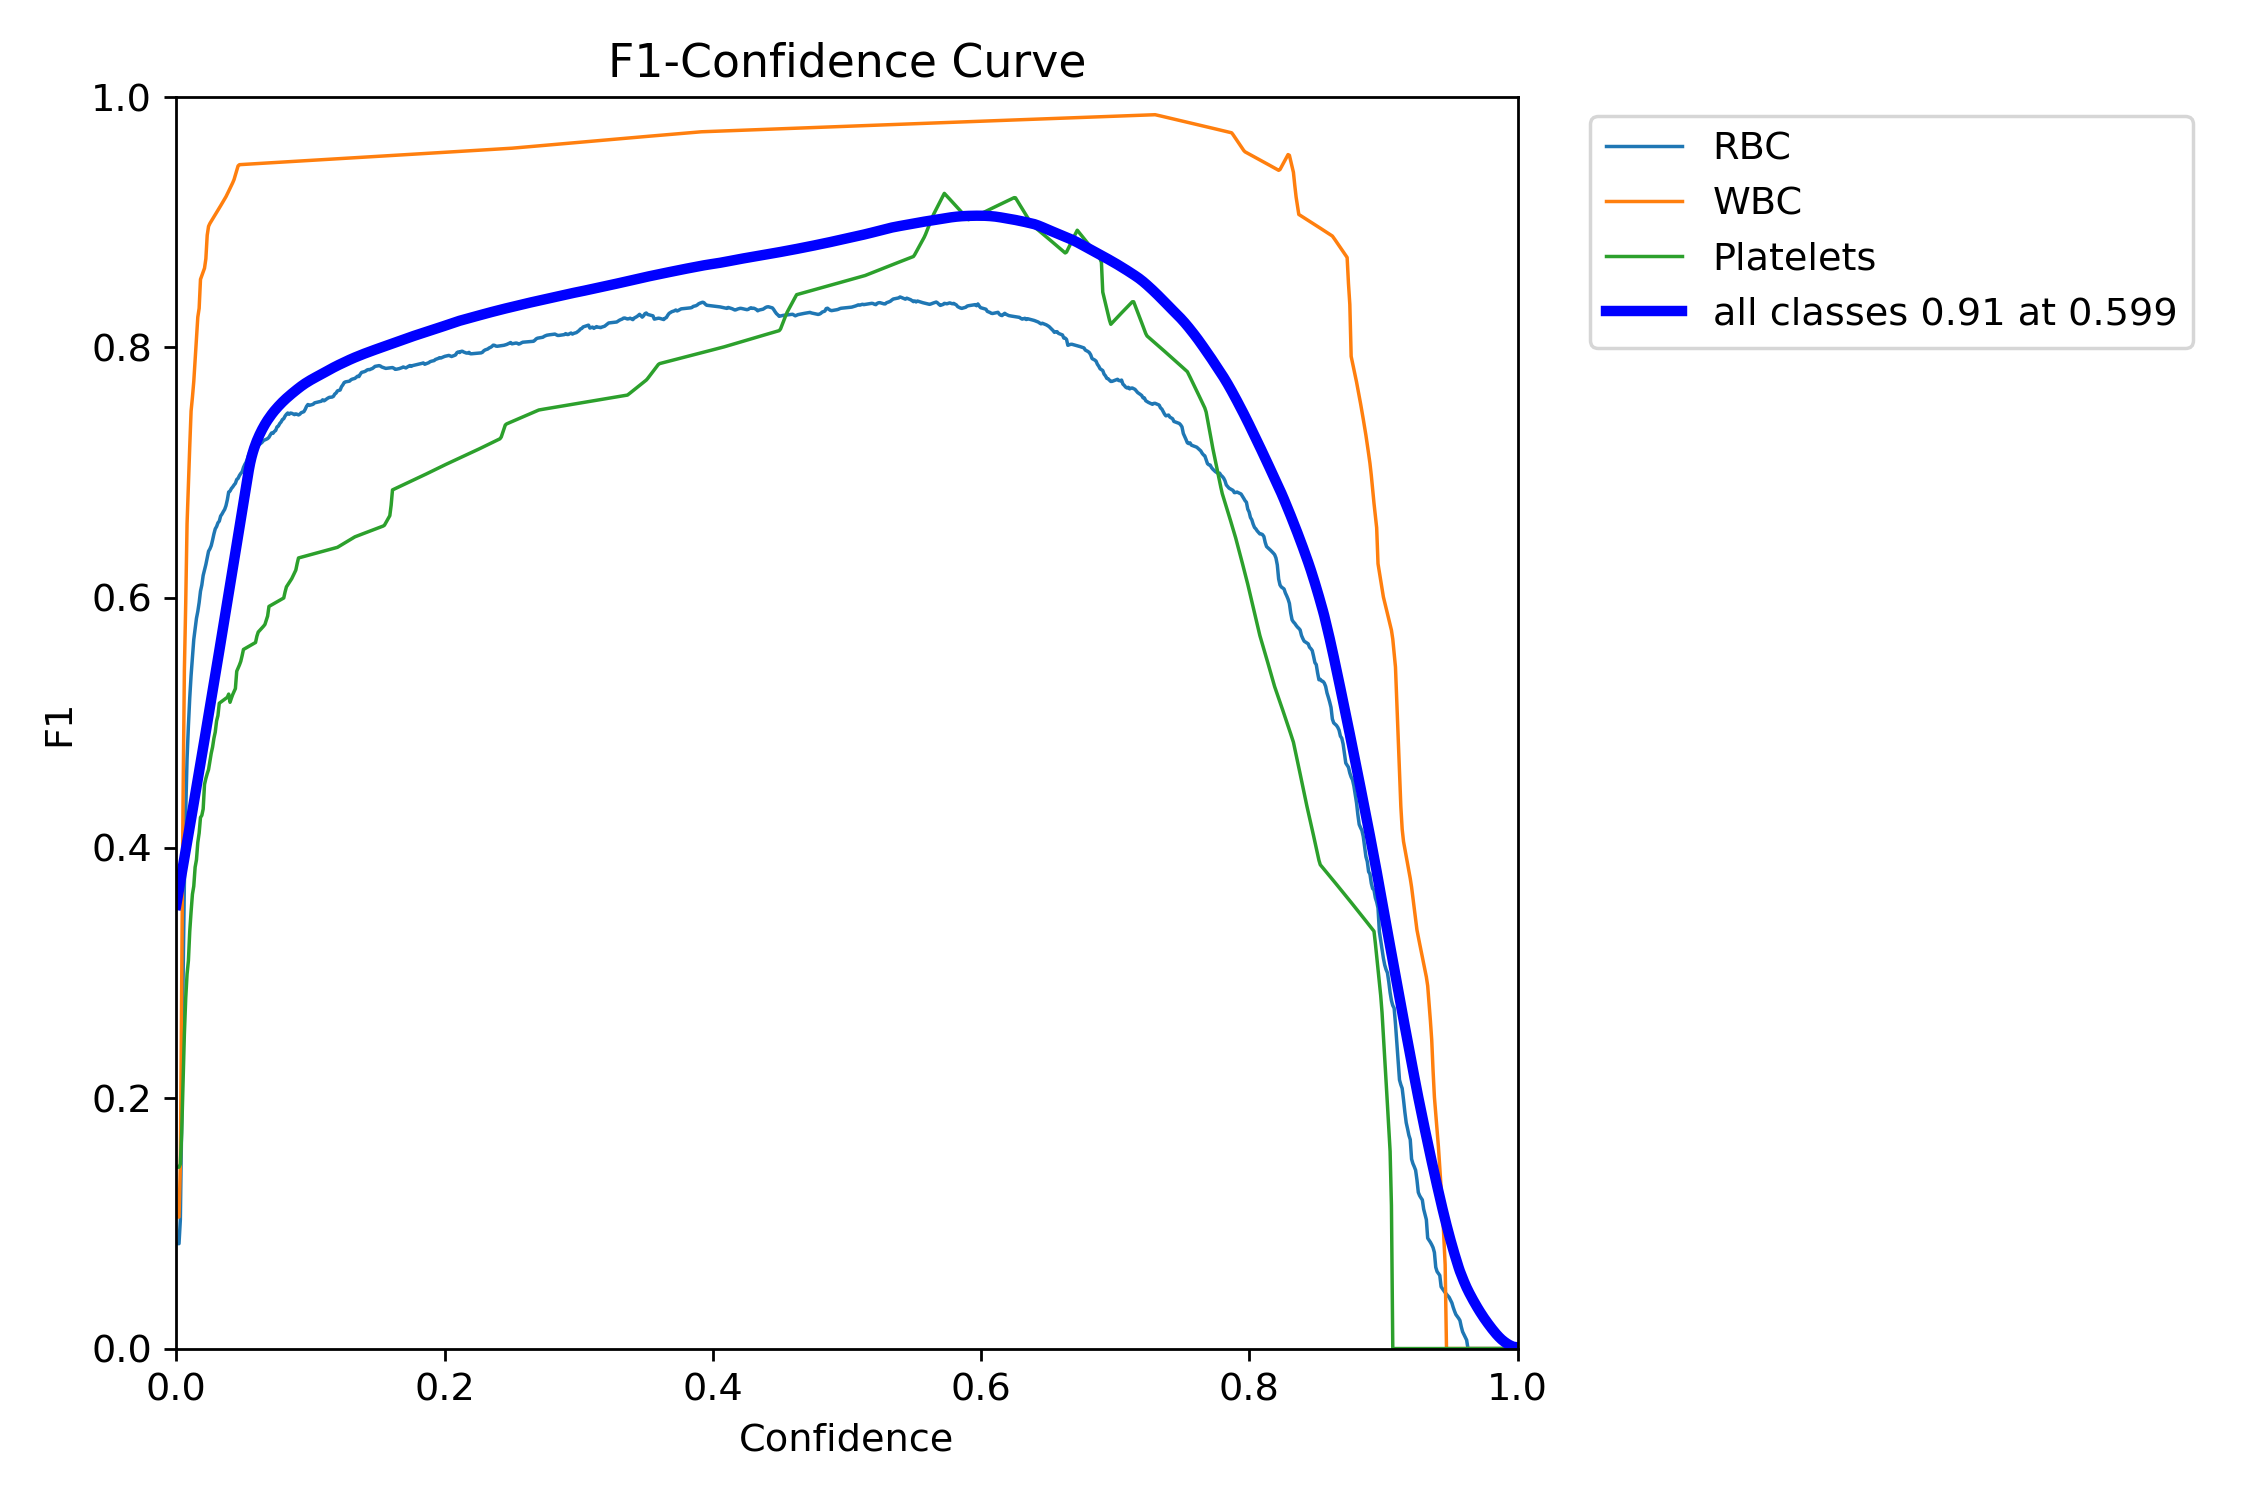


==================== PR Curve ====================



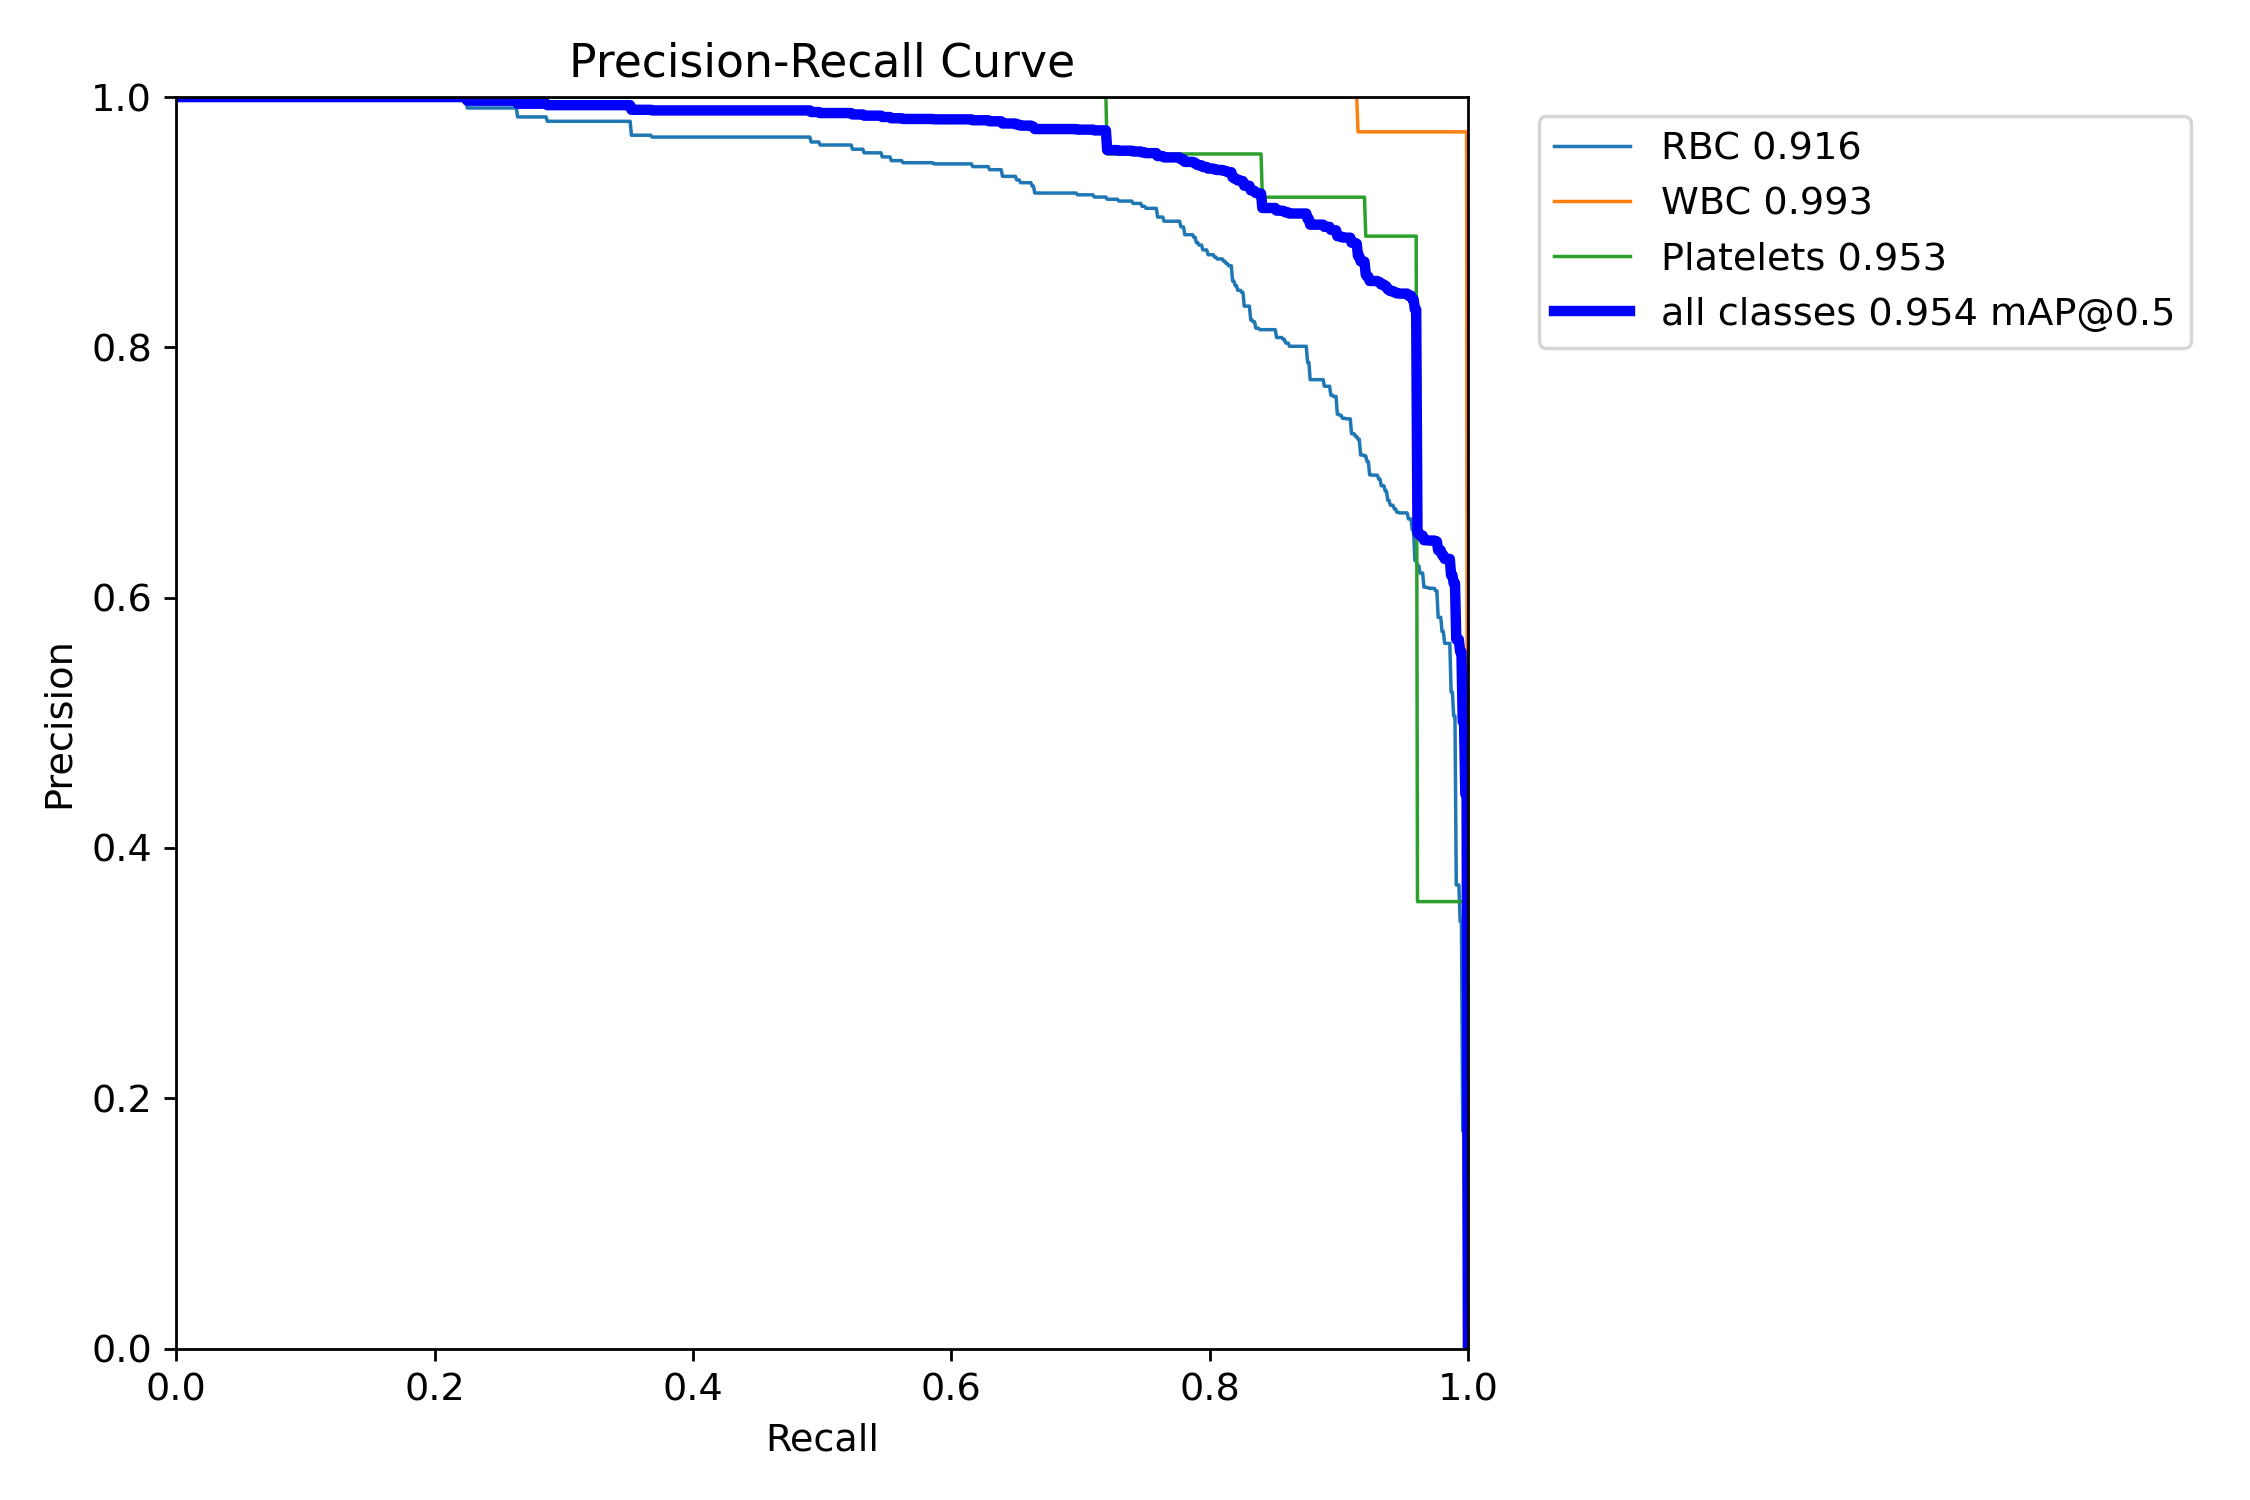

In [18]:
from IPython.display import Image, display

metrics = [
    ("Confusion Matrix", "/content/runs/detect/val/confusion_matrix.png", 700),
    ("Precision Curve", "/content/runs/detect/val/BoxP_curve.png", 900),
    ("Recall Curve", "/content/runs/detect/val/BoxR_curve.png", 900),
    ("F1 Curve", "/content/runs/detect/val/BoxF1_curve.png", 900),
    ("PR Curve", "/content/runs/detect/val/BoxPR_curve.png", 900),
]

for title, path, width in metrics:
    print(f"\n{'='*20} {title} {'='*20}\n")
    display(Image(filename=path, width=width))

In [21]:
import shutil

source = "/content/runs/detect/Rudhiraksha/YOLOv11_BloodCell/weights/best.pt"

destination = "/content/best.pt"

shutil.copy(source, destination)

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/best.pt"
)

In [24]:
import os
import random

valid_images_path = "/content/BCCD_YOLO/images/valid"

random_image = random.choice(
    os.listdir(valid_images_path)
)

random_image_path = os.path.join(
    valid_images_path,
    random_image
)

print("Selected Image:", random_image_path)

Selected Image: /content/BCCD_YOLO/images/valid/BloodImage_00202.jpg


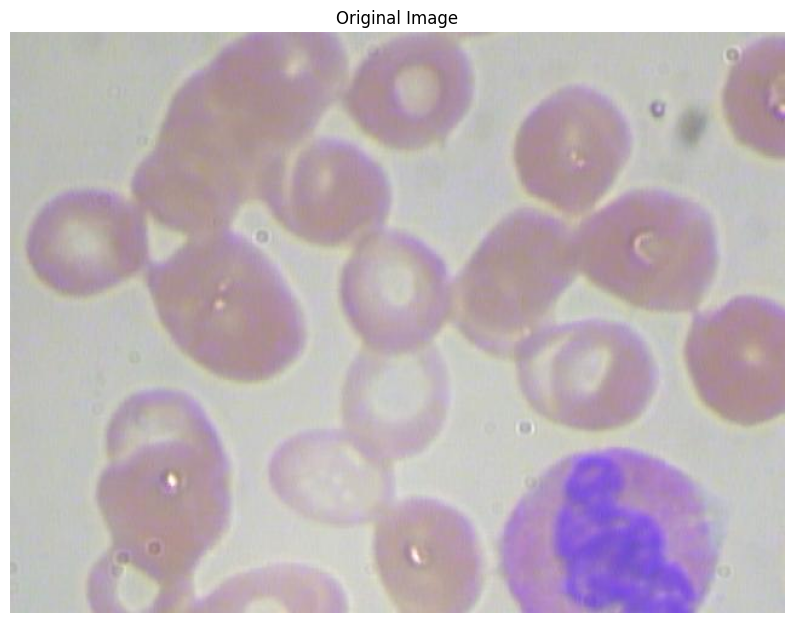

In [25]:
import glob

output_dir = results[0].save_dir

predicted_images = glob.glob(f"{output_dir}/*.jpg")

pred_img = cv2.imread(predicted_images[0])

pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,12))
plt.imshow(pred_img)
plt.axis("off")
plt.title("YOLOv11 Detection Output")
plt.show()

In [26]:
results = best_model.predict(
    source=random_image_path,
    conf=0.25,
    save=True
)


image 1/1 /content/BCCD_YOLO/images/valid/BloodImage_00202.jpg: 480x640 18 RBCs, 1 WBC, 116.1ms
Speed: 1.9ms preprocess, 116.1ms inference, 3.0ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


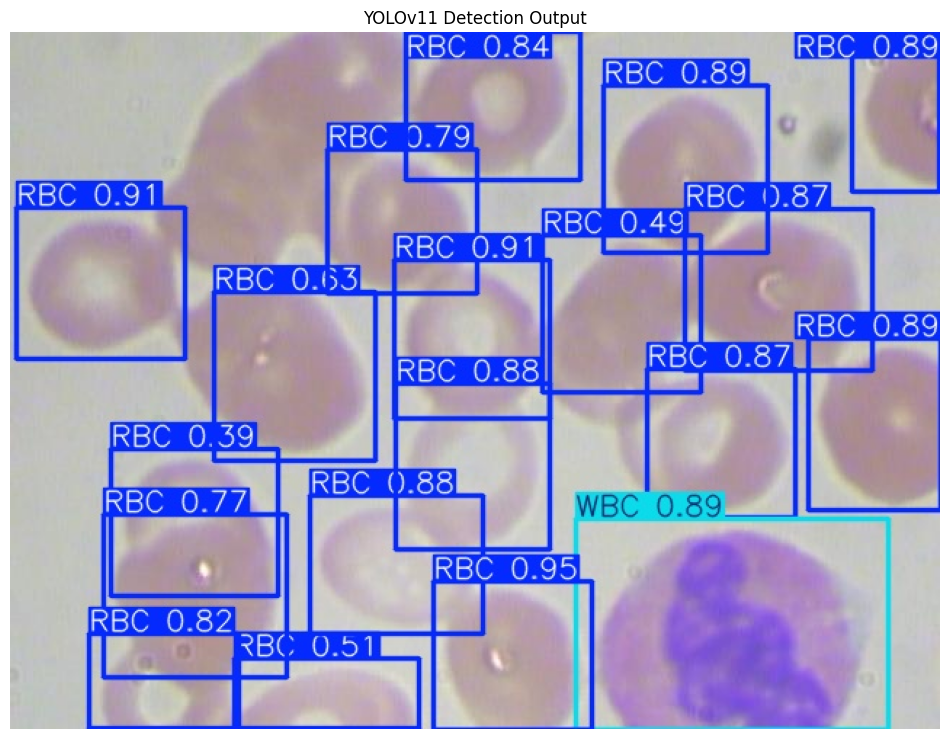

In [27]:
import glob

prediction_dir = results[0].save_dir

predicted_images = glob.glob(f"{prediction_dir}/*.jpg")

pred_img = cv2.imread(predicted_images[0])

pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,12))
plt.imshow(pred_img)
plt.title("YOLOv11 Detection Output")
plt.axis("off")
plt.show()

In [28]:
class_names = ['RBC', 'WBC', 'Platelets']

for r in results:

    boxes = r.boxes

    print(f"\nTotal Detections: {len(boxes)}\n")

    for box in boxes:

        cls_id = int(box.cls[0])
        confidence = float(box.conf[0])

        print(
            f"Class: {class_names[cls_id]} | "
            f"Confidence: {confidence:.4f}"
        )


Total Detections: 19

Class: RBC | Confidence: 0.9545
Class: RBC | Confidence: 0.9111
Class: RBC | Confidence: 0.9074
Class: RBC | Confidence: 0.8949
Class: WBC | Confidence: 0.8899
Class: RBC | Confidence: 0.8879
Class: RBC | Confidence: 0.8857
Class: RBC | Confidence: 0.8788
Class: RBC | Confidence: 0.8763
Class: RBC | Confidence: 0.8722
Class: RBC | Confidence: 0.8712
Class: RBC | Confidence: 0.8437
Class: RBC | Confidence: 0.8214
Class: RBC | Confidence: 0.7854
Class: RBC | Confidence: 0.7681
Class: RBC | Confidence: 0.6329
Class: RBC | Confidence: 0.5135
Class: RBC | Confidence: 0.4884
Class: RBC | Confidence: 0.3865
